In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel
from sklearn.preprocessing import power_transform
from scipy.stats import norm

# **Function 2** — Mystery ML Model

A black-box model taking two inputs and returning a log-likelihood score. Goal is to maximise that score on a noisy, multi-peaked surface.

- **Optimisation Goal:** Maximise
- **Input:** 2D
- **All-time best:** 0.560 at [0.689, 0.011] (Week 4)

Loading the cumulative dataset and appending the Week 7 result.

In [2]:
# Load current cumulative dataset (original + prior weekly updates) for Function 2
X = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_2/initial_inputs.npy')
Y = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_2/initial_outputs.npy')

# New data for Week 8 (Function 2)
X_w8_new_point = np.array([0.730653, 0.213258], dtype=np.float64)
Y_w8_new_point = np.array([0.4880938721880099], dtype=np.float64)

# Append the new data point
X_updated = np.vstack((X, X_w8_new_point.reshape(1, -1)))

# Remove duplicate X rows (if point already exists)
X_unique, unique_indices = np.unique(X_updated, axis=0, return_index=True)

# Build Y and keep matching rows only
Y_all = np.append(Y, Y_w8_new_point)
Y_updated = Y_all[unique_indices]

# Save updated arrays
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_2/initial_inputs.npy', X_unique)
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_2/initial_outputs.npy', Y_updated)

# Show updated arrays
print("Updated Inputs (X) - Function 2: ", X_unique)
print("Updated Outputs (Y) - Function 2: ", Y_updated)

Updated Inputs (X) - Function 2:  [[0.14269907 0.34900513]
 [0.33864816 0.21386725]
 [0.34174959 0.02869772]
 [0.43816606 0.68501826]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.638512   0.01429   ]
 [0.656253   0.988919  ]
 [0.66579958 0.12396913]
 [0.688961   0.010598  ]
 [0.69697    0.070707  ]
 [0.70263656 0.9265642 ]
 [0.730653   0.213258  ]
 [0.736899   0.001     ]
 [0.84527543 0.71112027]
 [0.871256   0.999348  ]
 [0.87779099 0.7786275 ]
 [0.998312   0.002851  ]]
Updated Outputs (Y) - Function 2:  [-0.06562362 -0.01385762  0.03874902  0.24461934  0.21496451  0.02310555
  0.29668333  0.51976639  0.53899612  0.55966119  0.49414992  0.61120522
  0.48809387  0.37180079  0.29399291  0.05410069  0.42058624 -0.08088786]


## **Output Analysis**
- w8 returned 0.488 at [0.731, 0.213], while this is a positive result, the all-time best remains 0.560 at [0.689, 0.011] from Week 4.

- **Real-World Implication**: This function likely represents a "log-likelihood" score, where we are looking for the most probable settings for a model. 
    - In these types of problems, the peak is often very narrow.Our current strategy is getting distracted.
    - Even though we told the search to stay near the best-known point, it wandered off to a coordinate ($x_2=0.213$) that is very far from where we know the success is.
    
- Model Clues: The search algorithm (UCB) is currently not effective.
    - It sees areas where it hasn't looked yet and assumes they might be better just because they are unknown.
    - The fact that $x_2=0.213$ produced a lower score than $x_2=0.011$ confirms that the high-reward zone is likely a thin strip or a small island near the bottom of the map.
    
- **Key change for w9**: Stop using the curiosity-based search (UCB) and switch to Expected Improvement (EI). 
    - I am also tightening the focus to keep the search on a very short area around the Week 4 best.

## **Bayesian Optimisation**
- **Model**: Gaussian Process Regressor using a Matern (nu=2.5) kernel.

- **Reasoning**: The model itself is working well, but the way we choose the next point needs to change. 
    - The Matern kernel is excellent at recognizing smooth hills, and the transformation helps the model see the difference between "good" results and "great" results more clearly.

- **Intended impact**: Force the model to stop exploring the empty corners of the map and start exploiting area we know works.

In [3]:
Y_transformed = power_transform(Y_updated.reshape(-1, 1), method='yeo-johnson').ravel()

kernel = Matern(nu=2.5) + WhiteKernel(noise_level=1e-5)
model = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=20)
model.fit(X_unique, Y_transformed)

,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",Matern(length...e_level=1e-05)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-10
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",20
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`

## **Acquisition Function**: Expected Improvement (EI)

- **Strategy**: Switch from UCB to EI with $\xi=0.01$.
- **Reasoning**: Imagine UCB is an explorer who wants to visit every blank spot on a map. 
    - EI is a gold miner who only wants to dig where there is a high probability of finding more gold than they already have.
    - By using EI, we "anchor" the search to our 0.560 record. 
    - The algorithm now has to prove a new spot is actually likely to beat that record before it’s allowed to go there.
    
- **Grid Setup**: A focused collection of points centered on [0.689, 0.011] with a very small spread (std=0.02).

- **Intended impact**: Keep the query locked into the $x_2 \approx 0.01$ region to finally break past the 0.560 ceiling.

In [7]:
def expected_improvement(X, model, y_max, xi=0.01):
    mu, sigma = model.predict(X, return_std=True)
    sigma = sigma.reshape(-1, 1)
    mu = mu.reshape(-1, 1)
    
    with np.errstate(divide='warn'):
        improvement = mu - y_max - xi
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

# Create focused grid around W4 Best
w4_best = np.array([0.689, 0.011])
# 80% Focused points, 20% Uniform points (to maintain w8 notebook logic)
X_focused = np.random.normal(loc=w4_best, scale=0.02, size=(8000, 2))
X_uniform = np.random.uniform(0, 1, size=(2000, 2))
X_candidates = np.vstack([X_focused, X_uniform])
X_candidates = np.clip(X_candidates, 0, 1)

# Selection
y_max = np.max(Y_transformed)
ei_values = expected_improvement(X_candidates, model, y_max, xi=0.01)
next_query = X_candidates[np.argmax(ei_values)]

print(f"Next Query Point (F2): {next_query[0]:.6f}-{next_query[1]:.6f}")

Next Query Point (F2): 0.703106-0.923905


## **Visualisation**

/var/folders/gb/k_dw_jpn7yl2j5x099l7d8840000gp/T/ipykernel_92235/1945142048.py:15: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x_plot[:, 0], x_plot[:, 1], cmap=cmap, s=2, alpha=0.8)


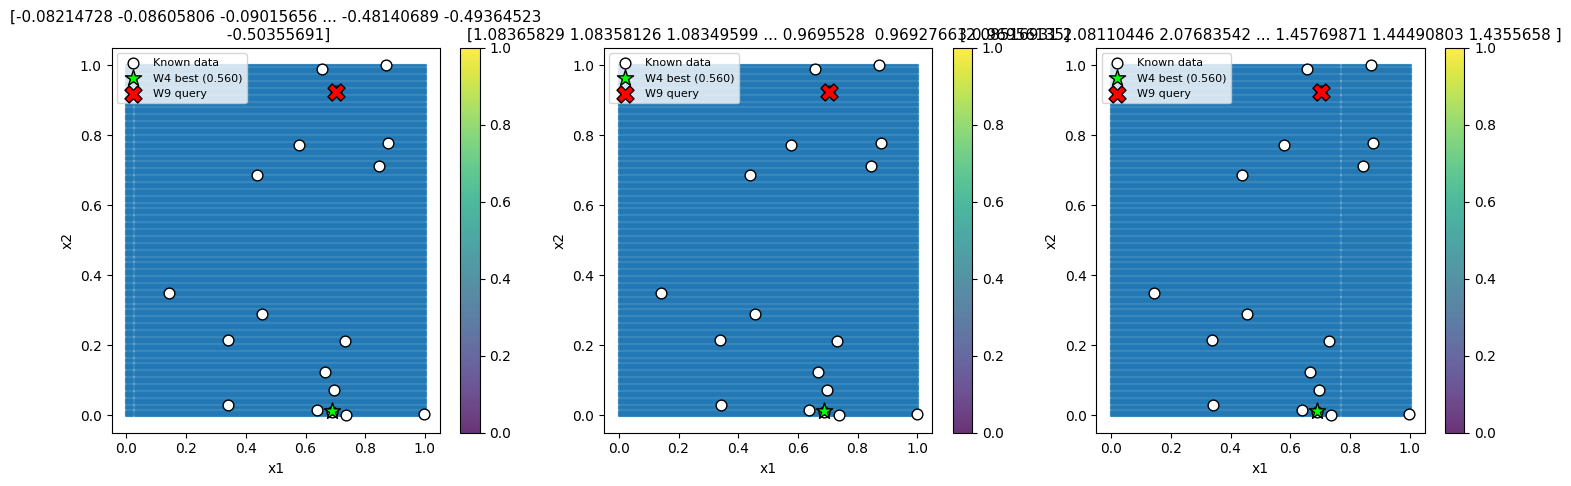

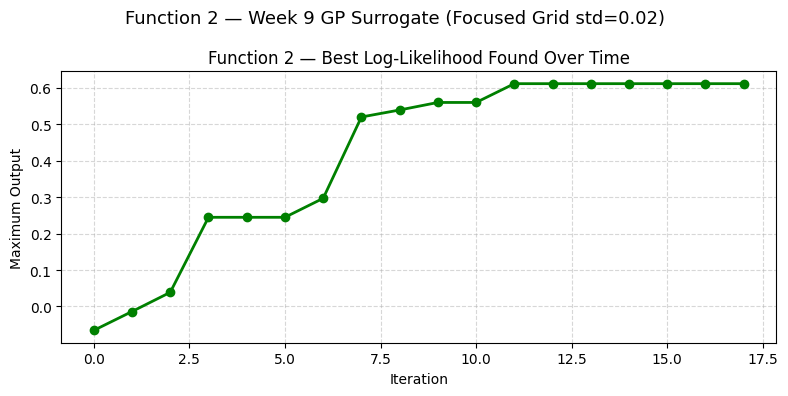

In [8]:
x_plot = np.array(np.meshgrid(
    np.linspace(0, 1, 150),
    np.linspace(0, 1, 150)
)).T.reshape(-1, 2)

mu_grid, sigma_grid = model.predict(x_plot, return_std=True)
ucb_plot = mu_grid + 2.0 * sigma_grid

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles   = ['GP Mean (Transformed)', 'GP Uncertainty (Sigma)', 'UCB Acquisition Surface']
surfaces = [mu_grid, sigma_grid, ucb_plot]
cmaps    = ['viridis', 'plasma', 'inferno']

for ax, surface, title, cmap in zip(axes, titles, surfaces, cmaps):
    sc = ax.scatter(x_plot[:, 0], x_plot[:, 1], cmap=cmap, s=2, alpha=0.8)
    ax.scatter(X_unique[:, 0], X_unique[:, 1],
               c='white', edgecolors='black', s=60, zorder=5, label='Known data')
    ax.scatter(w4_best[0], w4_best[1],
               c='lime', edgecolors='black', s=150, zorder=6, marker='*', label='W4 best (0.560)')
    ax.scatter(next_query[0], next_query[1],
               c='red', edgecolors='black', s=150, zorder=7, marker='X', label='W9 query')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    plt.colorbar(sc, ax=ax)
    ax.legend(fontsize=8)

running_max = np.maximum.accumulate(Y_updated)
fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.plot(running_max, marker='o', color='green', linewidth=2)
ax2.set_title('Function 2 — Best Log-Likelihood Found Over Time')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Maximum Output')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Function 2 — Week 9 GP Surrogate (Focused Grid std=0.02)', fontsize=13)
plt.tight_layout()
plt.show()